# Notebook 3 — Hypothesis Testing with Permutation Tests

**Hypothesis testing**: a method to ask "could this pattern have
arisen by chance?"

We'll use **permutation tests** — a non-parametric method that
evaluates significance by shuffling data labels to build a null
distribution, rather than assuming any mathematical distribution.

---
## 1. Setup

In [90]:
import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.stats import hypergeom

sns.set_theme()
np.random.seed(42)

DATA = os.path.join('..', 'data')
SUB_DIR = os.path.join(DATA, 'subfamilies')

def read_fasta(path):
    seqs = {}
    header = None
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line.startswith('>'):
                header = line[1:].split()[0]
                seqs[header] = ''
            elif header:
                seqs[header] += line
    return seqs

---
## 2. Enrichment: Colored Balls

Imagine a bag with **100 balls** of 5 colors:

| Color | Count |
|-------|-------|
| Purple | 20 |
| Red | 30 |
| Blue | 25 |
| Green | 15 |
| Yellow | 10 |

You grab a **subset of 15 balls** and count: **8 are purple**.

Purple is 20% of the bag, so you'd expect about 3 purple in 15
draws. But you got 8.

**Is purple enriched in your subset, or was it just accidental?**

### The concept

The large circle is the **population**. The small circle is our **subset**. Notice how purple is over-represented in the subset.

![Population of balls](../figures/enrichment_schema.png "Coloured balls")

### Expected vs Observed

In [91]:
# The population
population = (['purple'] * 20 + ['red'] * 30 + ['blue'] * 25
              + ['green'] * 15 + ['yellow'] * 10)

# What we observed in our subset of 15
observed = {'purple': 8, 'red': 3, 'blue': 2, 'green': 1, 'yellow': 1}
subset_size = 15

# How many of each color in the full bag
bag = {'purple': 20, 'red': 30, 'blue': 25, 'green': 15, 'yellow': 10}

# Compare expected vs observed
print("Color", "\t", "Expected", "\t", "Observed", "\t", "Fold enrichment")
print("-" * 56)
for color in bag:
    expected = subset_size * bag[color] / 100
    fold = round(observed[color] / expected, 2)
    print(color, "\t", round(expected, 1), "\t\t", observed[color], "\t\t", fold)

Color 	 Expected 	 Observed 	 Fold enrichment
--------------------------------------------------------
purple 	 3.0 		 8 		 2.67
red 	 4.5 		 3 		 0.67
blue 	 3.8 		 2 		 0.53
green 	 2.2 		 1 		 0.44
yellow 	 1.5 		 1 		 0.67


### Is it significant? We'll use a permutation test

Randomly grab 15 balls from the bag thousands of times.
How often do we get 8 or more purple?

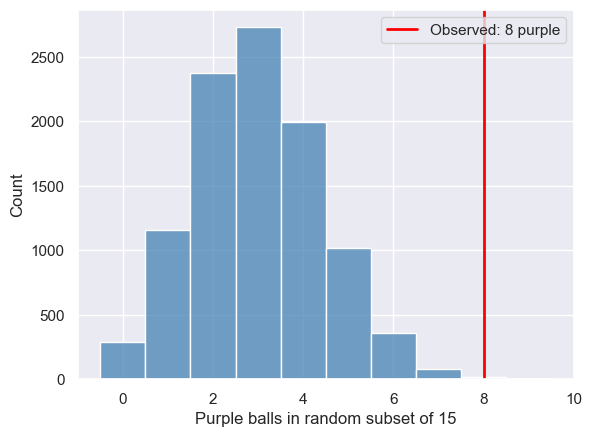

Permutation p-value: 0.0018


In [92]:
n_permutations = 10000
purple_counts = []

for i in range(n_permutations):
    random_grab = np.random.choice(population, size=subset_size,
                                   replace=False)
    purple_counts.append(np.sum(random_grab == 'purple'))

purple_counts = np.array(purple_counts)

# Plot
sns.histplot(purple_counts, bins=range(0, 13), discrete=True,
             color='steelblue')
plt.axvline(8, color='red', linewidth=2, label='Observed: 8 purple')
plt.xlabel('Purple balls in random subset of 15')
plt.legend()
plt.show()

p_perm = np.mean(purple_counts >= 8)
print("Permutation p-value:", p_perm)

---
## 3. Is echolocator body mass different?

Now a biological example. You measure the body mass of 12 mammals.
Five are echolocators, seven are not. The echolocators happen to
have a **higher average mass**. Is this significant, or could it
be explained by chance?

In [93]:
# Simulated body mass data (kg, made up for illustration)
masses = np.array([39, 42, 37, 50, 38, 45, 22, 31, 27, 33, 40, 36])
labels = np.array(['echo'] * 5 + ['non'] * 7)

echo_mean = masses[labels == 'echo'].mean()
non_mean  = masses[labels == 'non'].mean()
observed_diff = echo_mean - non_mean

print(f"Echolocator mean:     {echo_mean:.1f} kg")
print(f"Non-echolocator mean: {non_mean:.1f} kg")
print(f"Observed difference:  {observed_diff:.1f} kg")

Echolocator mean:     41.2 kg
Non-echolocator mean: 33.4 kg
Observed difference:  7.8 kg


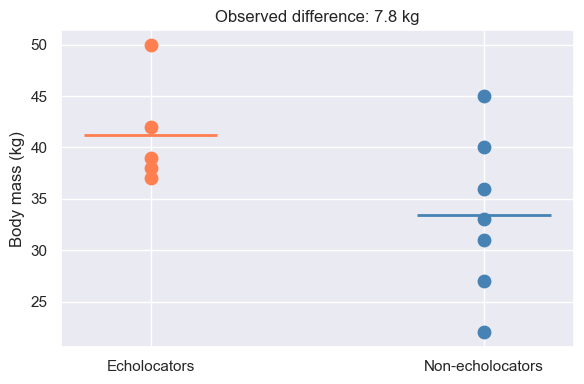

In [94]:
fig, ax = plt.subplots(figsize=(6, 4))
for i, (lab, col) in enumerate([('echo', 'coral'),
                                 ('non', 'steelblue')]):
    vals = masses[labels == lab]
    ax.scatter([i] * len(vals), vals, color=col, s=80, zorder=3)
    ax.hlines(vals.mean(), i - 0.2, i + 0.2, color=col, linewidth=2)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Echolocators', 'Non-echolocators'])
ax.set_ylabel('Body mass (kg)')
ax.set_title(f'Observed difference: {observed_diff:.1f} kg')
plt.tight_layout()
plt.show()

### Exercise 1 — Write the permutation test

1. Pool all 12 masses together
2. Randomly assign 5 of them to be "echolocators"
3. Compute the difference in means
4. Repeat 10,000 times
5. What fraction of random differences ≥ the observed difference?

**Plot** the null distribution as a histogram
and **mark** the observed difference with a red vertical line.

In [ ]:
# n_perm = 10000
# null_diffs = ...
#
# for i in range(n_perm):
#     ...
#
# p_value = ...
#
# # Plot the null distribution
# # Mark the observed difference
# # Print the p-value

### Exercise 2

1. Is the result significant at p < 0.05?
2. Try changing the echolocator masses to `[55, 60, 48, 52, 58]`.
   What happens to the p-value?
3. What if you only had 3 echolocators instead of 5? Does sample
   size matter?

In [ ]:
# Your code here

---
## 4. From numbers to amino acids

Instead of comparing *means of body mass*, we now ask: at specific
positions in the prestin alignment, do echolocators share amino
acids more than expected by chance?

Same logic — different data.

### 4.1 Load prestin alignment and species data

In [95]:
prestin_seqs = read_fasta(os.path.join(SUB_DIR, 'SLC26A5.trim.fa'))
names = list(prestin_seqs.keys())
aln = np.array([list(seq) for seq in prestin_seqs.values()])
n_species, n_pos = aln.shape
print(f"Prestin alignment: {n_species} species × {n_pos} positions")

Prestin alignment: 29 species × 757 positions


In [96]:
species_df = pd.read_csv(os.path.join(DATA, 'species_classification.tsv'),
                         sep='\t', comment='#')
# Handle different possible column names
ecol = [c for c in species_df.columns if c.startswith('echo')][0]
species_df['taxid'] = species_df['taxid'].astype(str)
echo_lookup = dict(zip(species_df['taxid'], species_df[ecol]))

taxids = [name.split('.')[0] for name in names]
is_echo = np.array([echo_lookup.get(t, 'no') == 'yes' for t in taxids])
n_echo = int(is_echo.sum())
print(f"Echolocators: {n_echo} / {n_species}")

Echolocators: 13 / 29


### 4.2 Agreement score

The **agreement score** at one position for a group of species:
fraction that shares the most common amino acid.

- All identical -> 1.0
- Split -> low

In [98]:
def agreement_score(residues):
    """Fraction of the most common amino acid (gaps ignored)."""
    filtered = [aa for aa in residues if aa != '-']
    if not filtered:
        return 0.0
    return Counter(filtered).most_common(1)[0][1] / len(filtered)

print(f"['A','A','A','A','A'] : {agreement_score(['A','A','A','A','A']):.2f}")
print(f"['A','A','A','G','G'] : {agreement_score(['A','A','A','G','G']):.2f}")
print(f"['A','G','L','K','D'] : {agreement_score(['A','G','L','K','D']):.2f}")

['A','A','A','A','A'] : 1.00
['A','A','A','G','G'] : 0.60
['A','G','L','K','D'] : 0.20


### 4.3 Permutation test at one position

**Null hypothesis:** echolocators are no more similar among them
than any random group of the same size.

**Test:** pick random subsets of the same size, compare their
agreement to what echolocators actually show.

In [101]:
pos = 200

echo_aas = aln[is_echo, pos]
obs_agreement = agreement_score(echo_aas)
print(f"Position {pos}")
print(f"  Echolocator AAs:  {list(echo_aas)}")
print(f"  Agreement score:  {obs_agreement:.2f}")

Position 200
  Echolocator AAs:  [np.str_('L'), np.str_('L'), np.str_('L'), np.str_('L'), np.str_('L'), np.str_('M'), np.str_('L'), np.str_('L'), np.str_('L'), np.str_('L'), np.str_('L'), np.str_('L'), np.str_('L')]
  Agreement score:  0.92


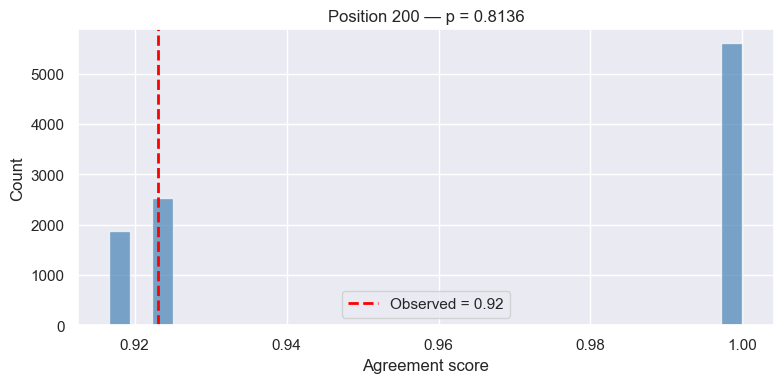

In [102]:
n_perm = 10000
null_agreements = np.zeros(n_perm)

for i in range(n_perm):
    idx = np.random.choice(n_species, size=n_echo, replace=False)
    null_agreements[i] = agreement_score(aln[idx, pos])

pval = np.mean(null_agreements >= obs_agreement)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_agreements, bins=30, color='steelblue', alpha=0.7,
        edgecolor='white')
ax.axvline(obs_agreement, color='red', linewidth=2, linestyle='--',
           label=f'Observed = {obs_agreement:.2f}')
ax.set_xlabel('Agreement score')
ax.set_ylabel('Count')
ax.set_title(f'Position {pos} — p = {pval:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

Same logic as the balls and the body mass: compute a statistic,
shuffle labels, see how extreme the real value is.

### Exercise 3

Try a few other positions. Can you find one where echolocators
clearly agree (p < 0.01) and one where they don't?

In [ ]:
# Your code here

---
## 5. Scanning the whole alignment

Now we test **every** position to find where echolocators converge.

In [105]:
n_perm = 1000
results = []

print(f"Scanning {n_pos} positions ({n_perm} permutations each)...")
for pos in range(n_pos):
    obs = agreement_score(aln[is_echo, pos])

    count = 0
    for _ in range(n_perm):
        idx = np.random.choice(n_species, size=n_echo, replace=False)
        if agreement_score(aln[idx, pos]) >= obs:
            count += 1

    results.append({'position': pos, 'agreement': obs,
                    'pvalue': count / n_perm})

    if (pos + 1) % 100 == 0:
        print(f"  {pos + 1} / {n_pos}")

results_df = pd.DataFrame(results)
print("Finished")

Scanning 757 positions (1000 permutations each)...
  100 / 757
  200 / 757
  300 / 757
  400 / 757
  500 / 757
  600 / 757
  700 / 757
Finished


In [106]:
n_sig = (results_df['pvalue'] < 0.05).sum()
n_sig_strict = (results_df['pvalue'] < 0.01).sum()
print(f"Significant at p < 0.05:  {n_sig} / {n_pos}")
print(f"Significant at p < 0.01:  {n_sig_strict} / {n_pos}")

Significant at p < 0.05:  24 / 757
Significant at p < 0.01:  9 / 757


**Multiple testing.** We tested hundreds of positions, so some will
appear "significant" by chance. With 1000 positions at p < 0.05, we
expect ~50 false positives. Methods like Bonferroni correction
(divide threshold by number of tests) address this.

### 5.1 Manhattan plot

In [107]:
def shannon_entropy(column):
    residues = [aa for aa in column if aa != '-']
    if not residues:
        return 0.0
    counts = Counter(residues)
    total = len(residues)
    return -sum((c/total) * math.log2(c/total) for c in counts.values())

entropies = [shannon_entropy(list(aln[:, p])) for p in range(n_pos)]

/var/folders/bg/mb65kwgx0_vbvks48sb6m1jw0000gp/T/ipykernel_14956/148510250.py:20: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/bg/mb65kwgx0_vbvks48sb6m1jw0000gp/T/ipykernel_14956/148510250.py:20: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/mambaforge/base/envs/convergent-evo/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/mambaforge/base/envs/convergent-evo/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


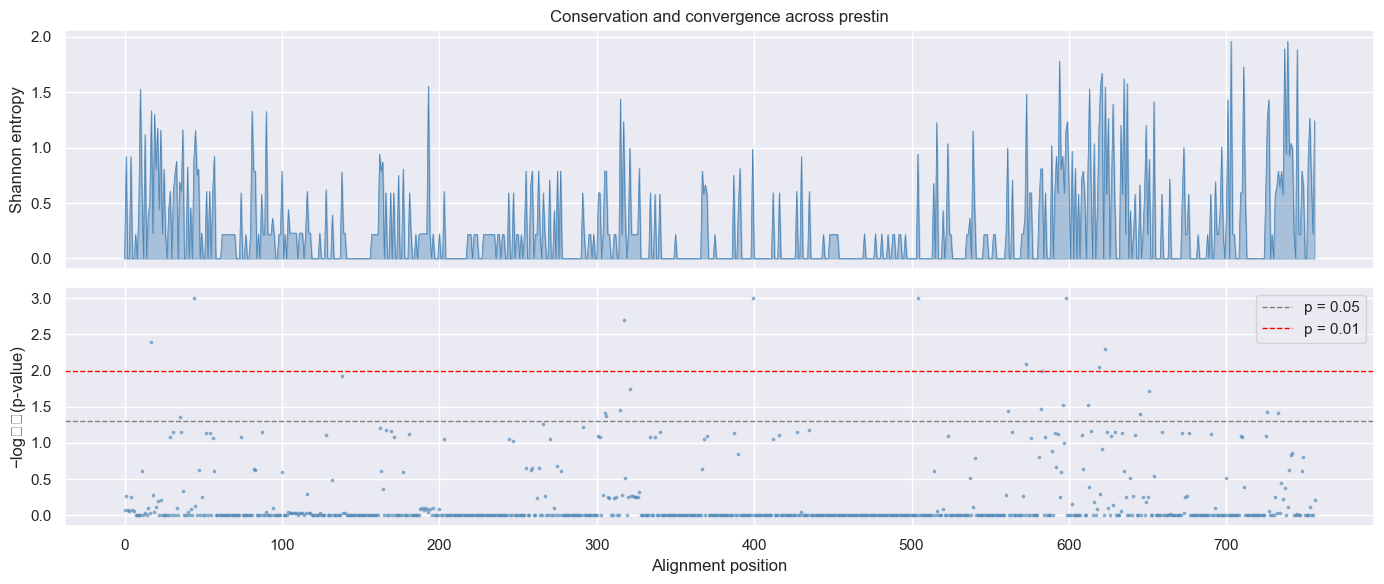

In [108]:
pvals = results_df['pvalue'].replace(0, 1 / (n_perm + 1))
neg_log_p = -np.log10(pvals)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].fill_between(range(n_pos), entropies, alpha=0.4, color='steelblue')
axes[0].plot(range(n_pos), entropies, linewidth=0.5, color='steelblue')
axes[0].set_ylabel('Shannon entropy')
axes[0].set_title('Conservation and convergence across prestin')

axes[1].scatter(range(n_pos), neg_log_p, s=3, c='steelblue', alpha=0.5)
axes[1].axhline(-np.log10(0.05), color='gray', linewidth=1, linestyle='--',
                label='p = 0.05')
axes[1].axhline(-np.log10(0.01), color='red', linewidth=1, linestyle='--',
                label='p = 0.01')
axes[1].set_xlabel('Alignment position')
axes[1].set_ylabel('−log₁₀(p-value)')
axes[1].legend()

plt.tight_layout()
plt.show()

Positions above the dashed lines show stronger echolocator agreement
than expected. Some fall in conserved regions (low entropy), but not
all — these are sites with **echolocator-specific** amino acid
preferences.

---
## 6. Summary

1. **Permutation tests** compute p-values by shuffling labels and
   comparing to a null distribution.
2. We applied this to colored balls, body mass, and amino acids.
3. At specific prestin positions, echolocators agree more than
   expected — evidence for **convergent evolution**.

**More rigorous analysis:**
- Phylogenetic correction (related species share AAs by descent)
- Ancestral reconstruction (true convergence vs shared ancestry)
- Correction for multiple testing

Parker et al. (2013) found genome-wide convergence across many
hearing genes.

---
## 7. Save results for the assignment

In [111]:
results_path = os.path.join(DATA, 'prestin_convergence_results.csv')
results_df.to_csv(results_path, index=False)
print(f"Saved convergence results in {results_path}")

entropy_df = pd.DataFrame({'position': range(n_pos),
                           'entropy': entropies})
entropy_path = os.path.join(DATA, 'prestin_entropy.csv')
entropy_df.to_csv(entropy_path, index=False)
print(f"Saved entropy values in {entropy_path}")

Saved convergence results in ../data/prestin_convergence_results.csv
Saved entropy values in ../data/prestin_entropy.csv
